In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')




In [ ]:
df = pd.read_csv('/content/customer_support_tickets (1).csv')
rows=df.shape[0]
columns=df.shape[1]
print(f"Number of Rows:{rows} , Number of columns:{columns} ")

Number of Rows:8469 , Number of columns:17 


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [ ]:
(df.head())

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [ ]:
(df.tail())

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
8464,8465,David Todd,adam28@example.net,22,Female,LG OLED,2021-12-08,Product inquiry,Installation support,My {product_purchased} is making strange noise...,Open,NaN,Low,Phone,NaN,NaN,NaN
8465,8466,Lori Davis,russell68@example.com,27,Female,Bose SoundLink Speaker,2020-02-22,Technical issue,Refund request,I'm having an issue with the {product_purchase...,Open,NaN,Critical,Email,NaN,NaN,NaN
8466,8467,Michelle Kelley,ashley83@example.org,57,Female,GoPro Action Camera,2021-08-17,Technical issue,Account access,I'm having an issue with the {product_purchase...,Closed,Eight account century nature kitchen.,High,Social media,2023-06-01 09:44:22,2023-06-01 04:31:22,3.0
8467,8468,Steven Rodriguez,fpowell@example.org,54,Male,PlayStation,2021-10-16,Product inquiry,Payment issue,I'm having an issue with the {product_purchase...,Closed,We seat culture plan.,Medium,Email,2023-06-01 18:28:24,2023-06-01 05:32:24,3.0
8468,8469,Steven Davis MD,lori20@example.net,53,Other,Philips Hue Lights,2020-06-01,Billing inquiry,Hardware issue,There seems to be a hardware problem with my {...,Open,NaN,High,Phone,NaN,NaN,NaN


In [ ]:
print(df.describe())

         Ticket ID  Customer Age  Customer Satisfaction Rating
count  8469.000000   8469.000000                   2769.000000
mean   4235.000000     44.026804                      2.991333
std    2444.934048     15.296112                      1.407016
min       1.000000     18.000000                      1.000000
25%    2118.000000     31.000000                      2.000000
50%    4235.000000     44.000000                      3.000000
75%    6352.000000     57.000000                      4.000000
max    8469.000000     70.000000                      5.000000


In [ ]:
print(df.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


**CHECKING FOR MISSING VALUES AND HANDLING THEM**

In [ ]:
missing_values=df.isnull().sum()
print(missing_values)

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [ ]:

missing_values = df.isnull().sum()
if missing_values.sum() == 0:
 print("No missing values found!")
else:
 print(missing_values[missing_values > 0])

Resolution                      5700
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage[missing_percentage > 0])


Resolution                      67.304286
First Response Time             33.286102
Time to Resolution              67.304286
Customer Satisfaction Rating    67.304286
dtype: float64


In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical columns : {len(numerical_cols)}   {list(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)} {list(categorical_cols)}")

Numerical columns : 3   ['Ticket ID', 'Customer Age', 'Customer Satisfaction Rating']
Categorical columns: 14 ['Customer Name', 'Customer Email', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution']


In [ ]:
# For numerical columns
for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"{col}: Filled with median ({median_value})")

Customer Satisfaction Rating: Filled with median (3.0)


In [ ]:
# For categorical columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = 'unknown'
        df[col].fillna(mode_value, inplace=True)
        print(f"{col}: Filled with mode {mode_value}")

Resolution: Filled with mode unknown
First Response Time: Filled with mode unknown
Time to Resolution: Filled with mode unknown


In [ ]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


**PERFORMING EDA-EXPLORATORY DATA ANALYSIS**

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, '1.0'),
  Text(1, 0, '2.0'),
  Text(2, 0, '3.0'),
  Text(3, 0, '4.0'),
  Text(4, 0, '5.0')])

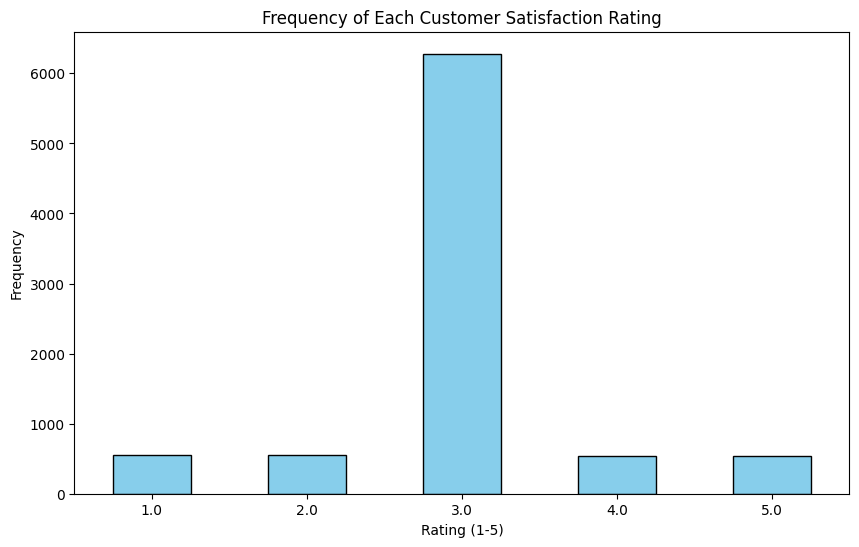

In [ ]:
# Count the frequency of each satisfaction rating
rating_counts = df['Customer Satisfaction Rating'].value_counts().sort_index()

# Create a bar chart
plt.figure(figsize=(10, 6))
rating_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Frequency of Each Customer Satisfaction Rating')
plt.xlabel('Rating (1-5)')
plt.ylabel('Frequency')
plt.xticks(rotation=0)

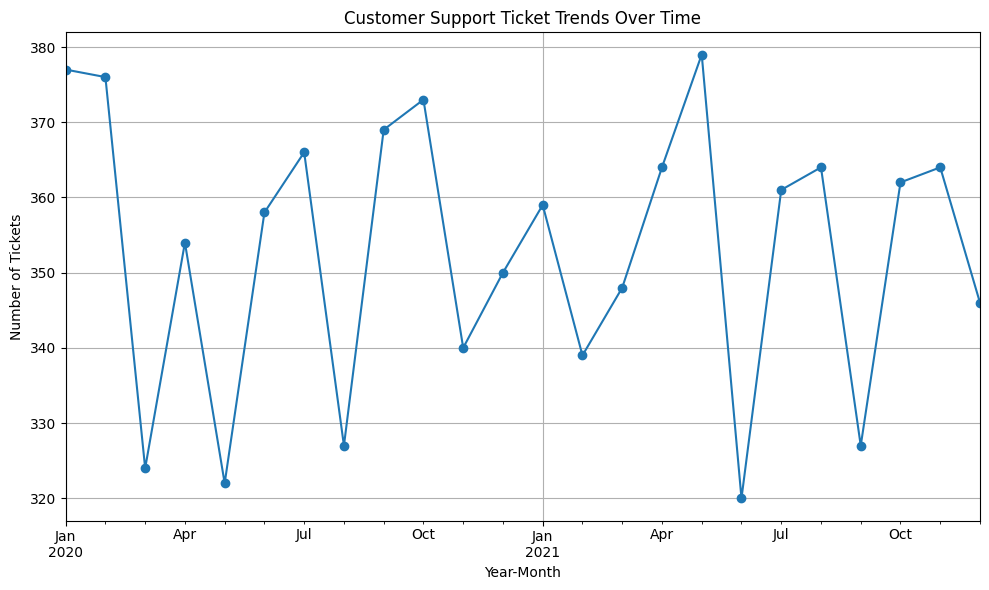

In [ ]:
#Plotting ticket trends over time

df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['Year-Month'] = df['Date of Purchase'].dt.to_period('M')
ticket_trends = df.groupby('Year-Month').size()
plt.figure(figsize=(10, 6))
ticket_trends.plot(kind='line', marker='o')
plt.title('Customer Support Ticket Trends Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Tickets')
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

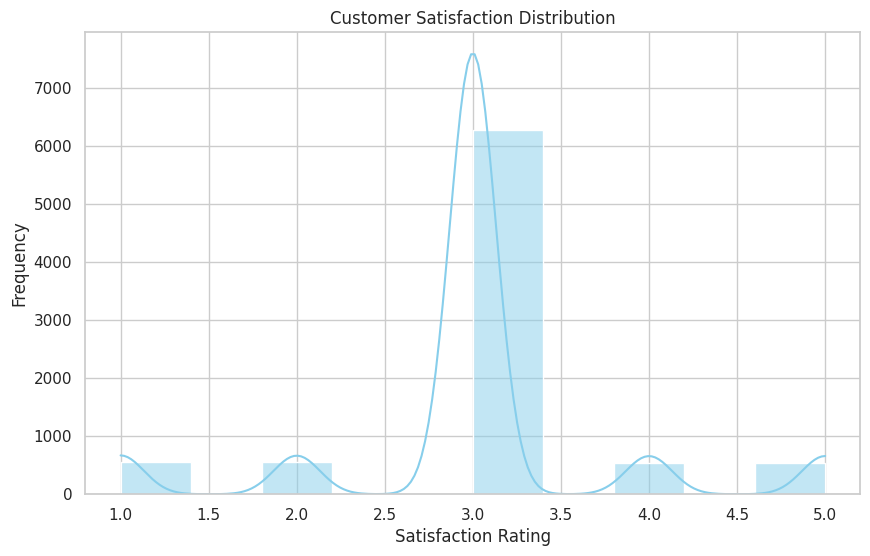

In [ ]:
# Set up the plotting aesthetics
sns.set(style="whitegrid")

#Customer Satisfaction Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Customer Satisfaction Rating'], bins=10, kde=True, color='skyblue')
plt.title('Customer Satisfaction Distribution')
plt.xlabel('Satisfaction Rating')
plt.ylabel('Frequency')
plt.show()

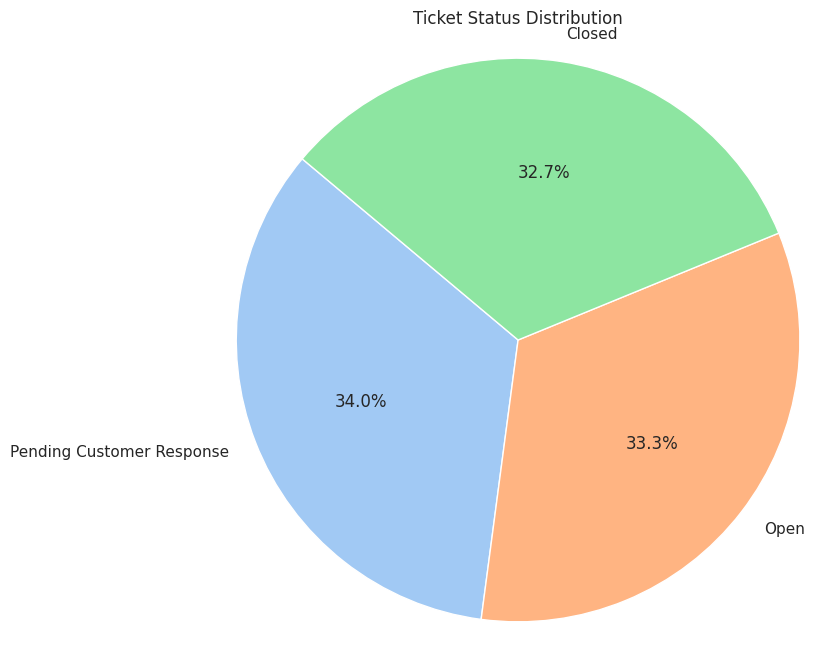

In [ ]:
#Ticket Status Distribution
ticket_status_distribution = df['Ticket Status'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(ticket_status_distribution,
labels=ticket_status_distribution.index, autopct='%1.1f%%',
colors=sns.color_palette('pastel'), startangle=140)
plt.title('Ticket Status Distribution')
plt.axis('equal')
plt.show()

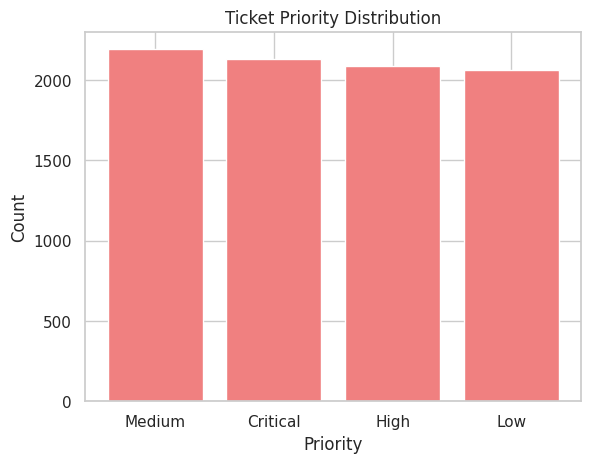

In [ ]:
if 'Ticket Priority' in df.columns:
  priority_counts = df['Ticket Priority'].value_counts()
plt.bar(priority_counts.index, priority_counts.values, color='lightcoral')
plt.title('Ticket Priority Distribution')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.show()

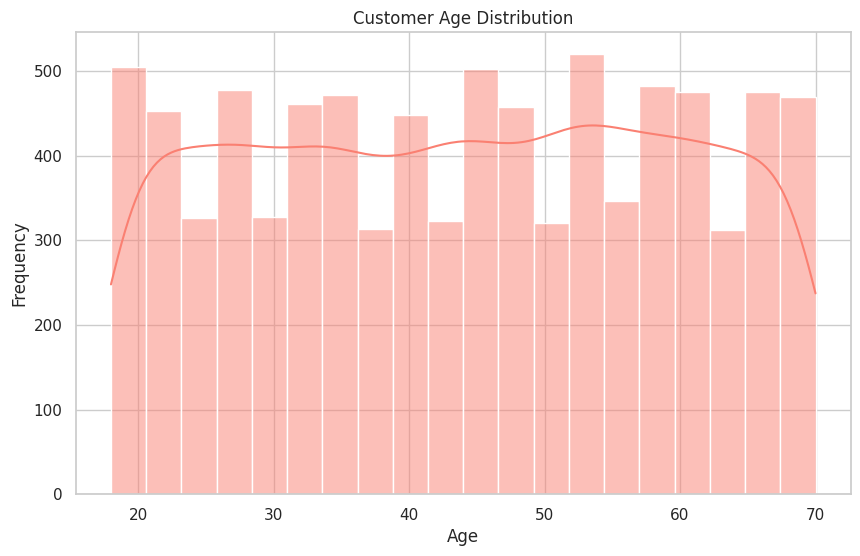

In [ ]:
#Customer Age Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Customer Age'], bins=20, kde=True,
color='salmon')
plt.title('Customer Age Distribution')
plt.xlabel('Age')

plt.ylabel('Frequency')
plt.show()

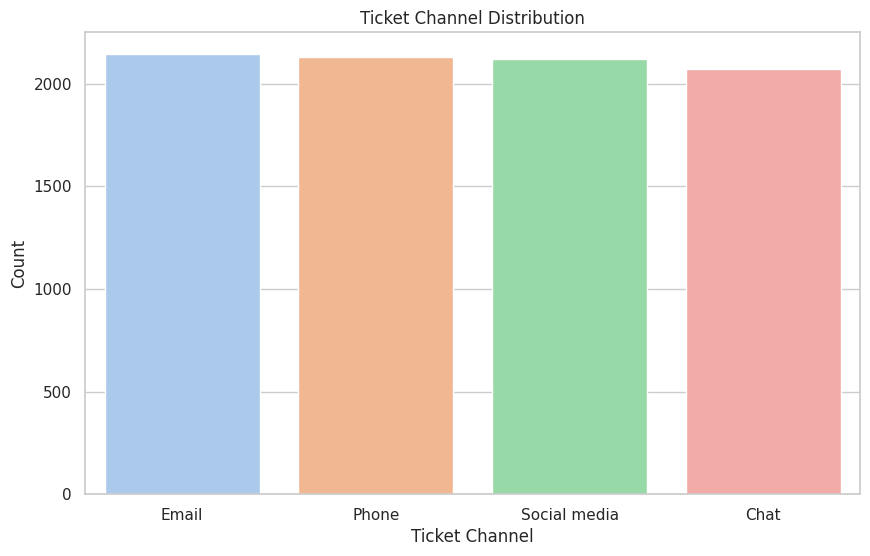

In [ ]:
#Ticket Channel Distribution
plt.figure(figsize=(10, 6))
ticket_channel_distribution = df['Ticket Channel'].value_counts()
sns.barplot(x=ticket_channel_distribution.index,

y=ticket_channel_distribution, palette='pastel')
plt.title('Ticket Channel Distribution')
plt.xlabel('Ticket Channel')
plt.ylabel('Count')
plt.show()

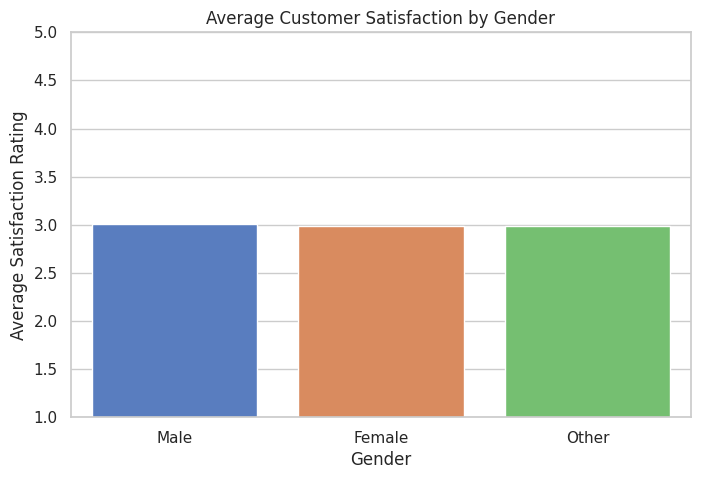

In [ ]:
# Average Customer Satisfaction by Gender

average_satisfaction = df.groupby('Customer Gender')['Customer Satisfaction Rating'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(x='Customer Gender', y='Customer Satisfaction Rating', data=average_satisfaction, palette='muted',
order=['Male', 'Female', 'Other'])
plt.title('Average Customer Satisfaction by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Satisfaction Rating')
plt.ylim(1, 5)
plt.show()

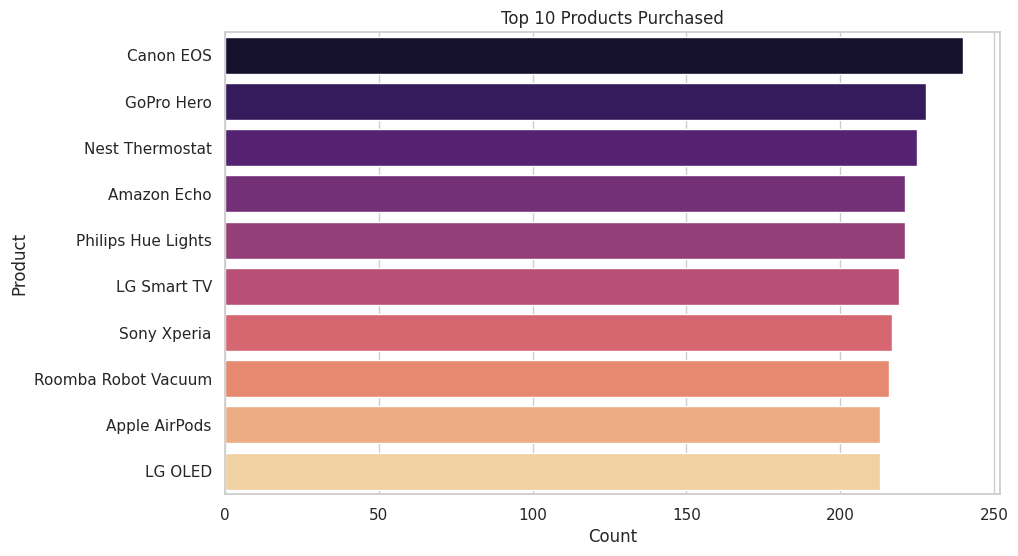

In [ ]:
# Product Purchased Distribution
plt.figure(figsize=(10, 6))
product_purchased_distribution = df['Product Purchased'].value_counts().head(10)
sns.barplot(y=product_purchased_distribution.index,
x=product_purchased_distribution, palette='magma')
plt.title('Top 10 Products Purchased')
plt.xlabel('Count')
plt.ylabel('Product')
plt.show()

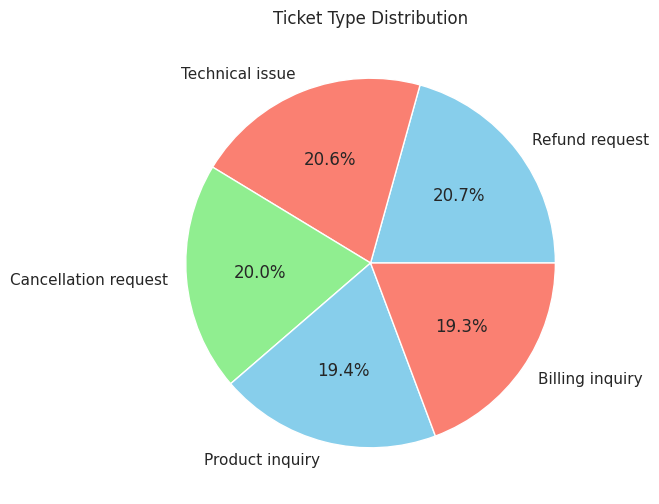

In [ ]:
# Count ticket types
ticket_type_distribution = df['Ticket Type'].value_counts()
plt.figure(figsize=(8, 6))
ticket_type_distribution.plot(kind='pie', autopct='%1.1f%%',
colors=['skyblue', 'salmon', 'lightgreen'])
plt.title('Ticket Type Distribution')
plt.ylabel('')
plt.show()

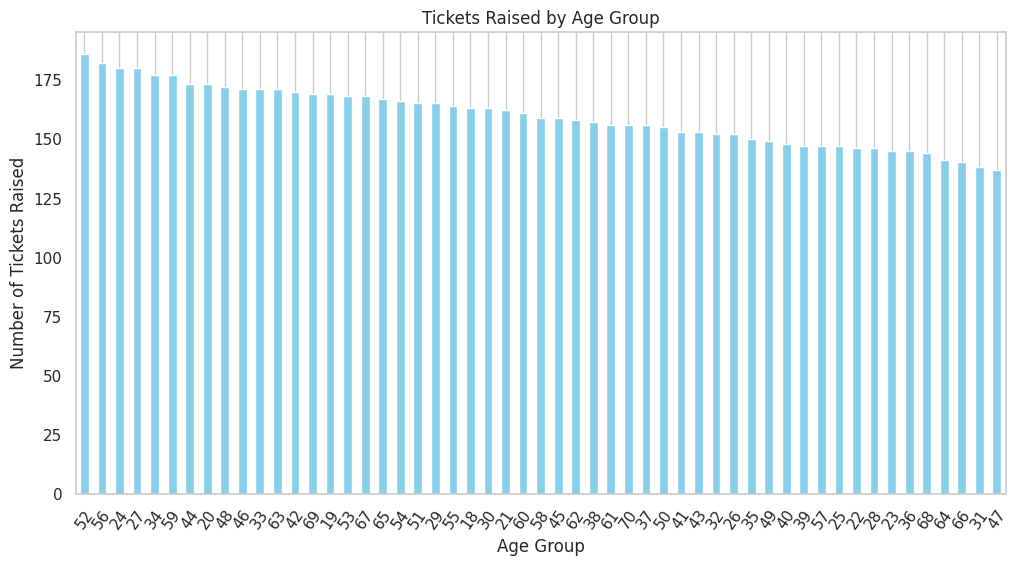

In [ ]:
ticket_age_group = df['Customer Age'].value_counts()
plt.figure(figsize=(12, 6))
ticket_age_group.plot(kind='bar', color='skyblue')
plt.title('Tickets Raised by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Tickets Raised')
plt.xticks(rotation=55)
plt.grid(axis='y')
plt.show()

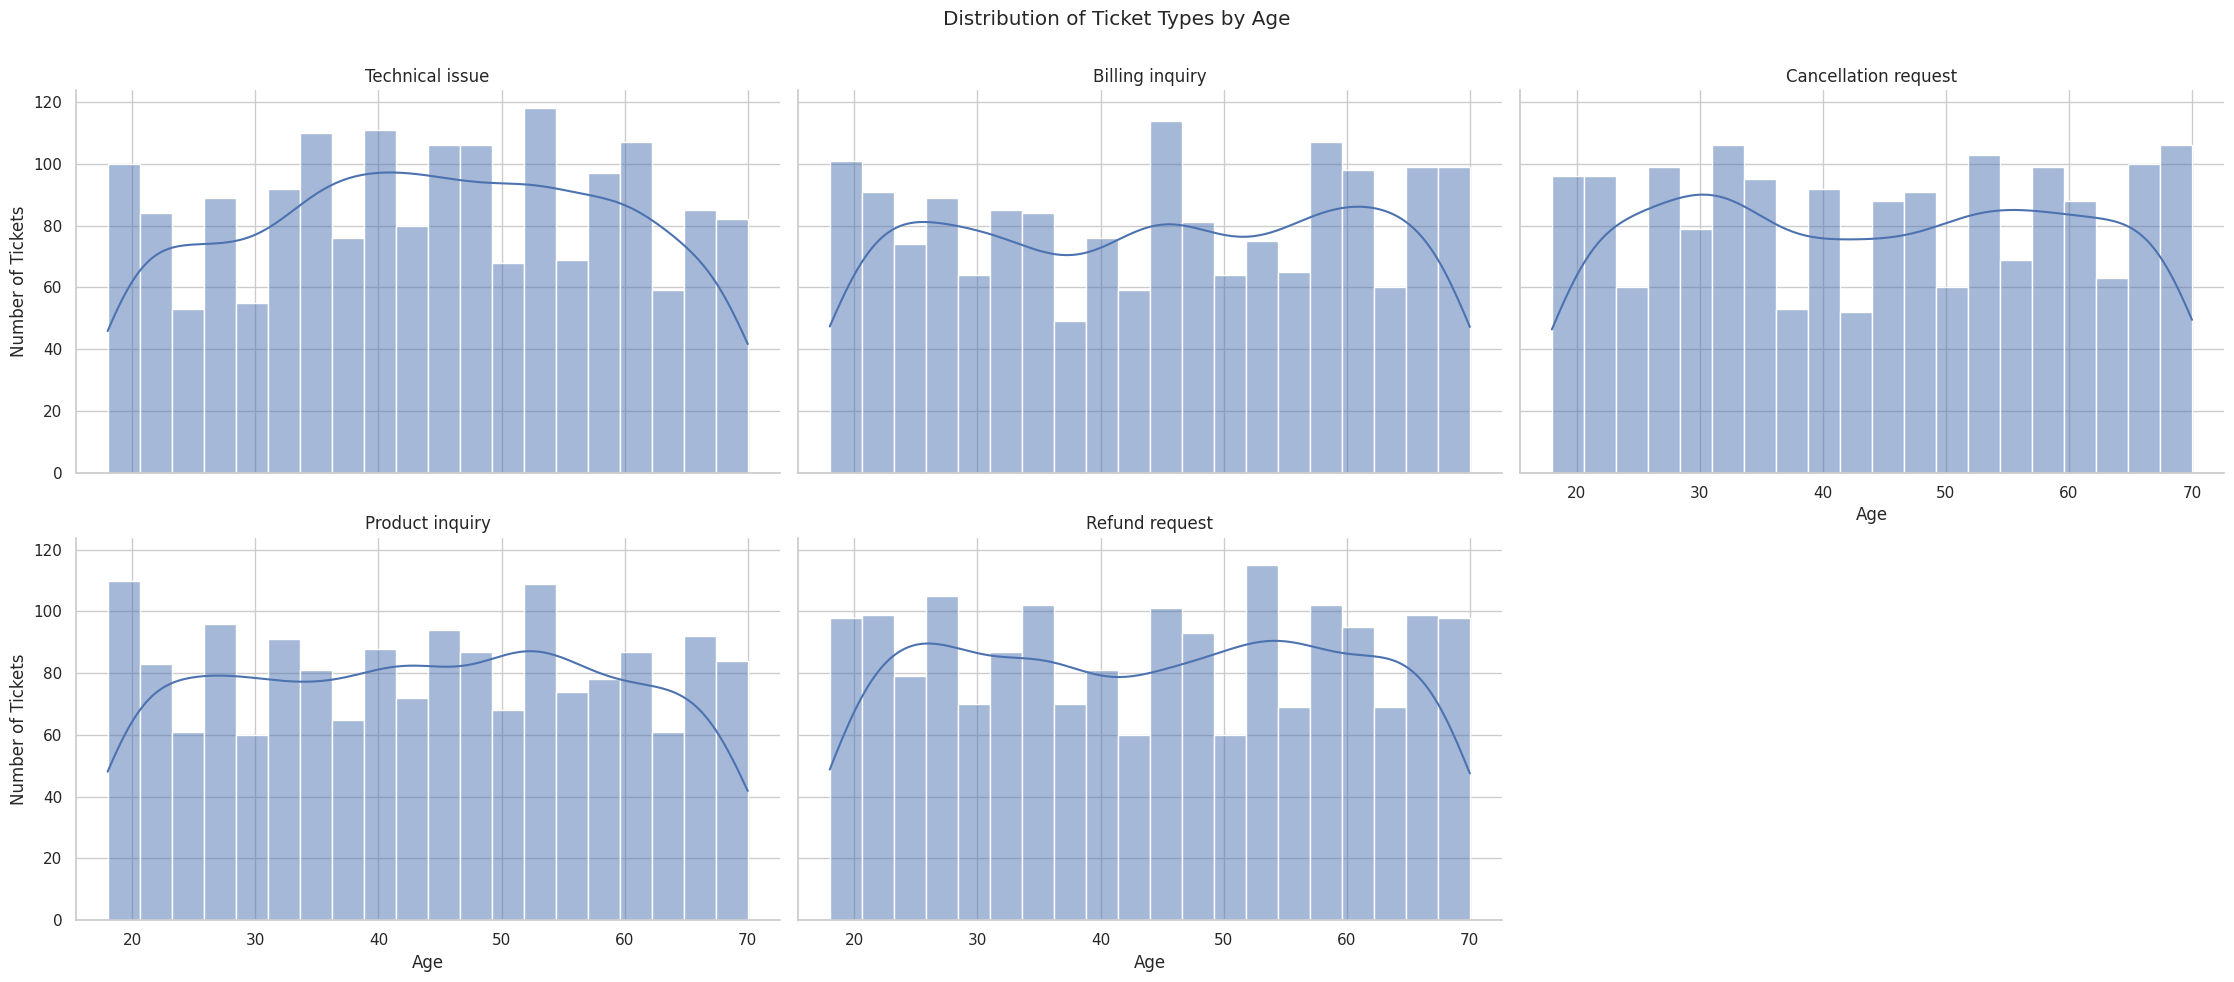

In [ ]:
# Replace inf values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Create a facet grid for each ticket type
g = sns.FacetGrid(df, col='Ticket Type', col_wrap=3,height=5, aspect=1.5)
g.map(sns.histplot, 'Customer Age', bins=20, kde=True)

# Set titles and labels
g.set_titles('{col_name}')
g.set_axis_labels('Age', 'Number of Tickets')

# Adjust layout
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of Ticket Types by Age')

# Show plot
plt.show()

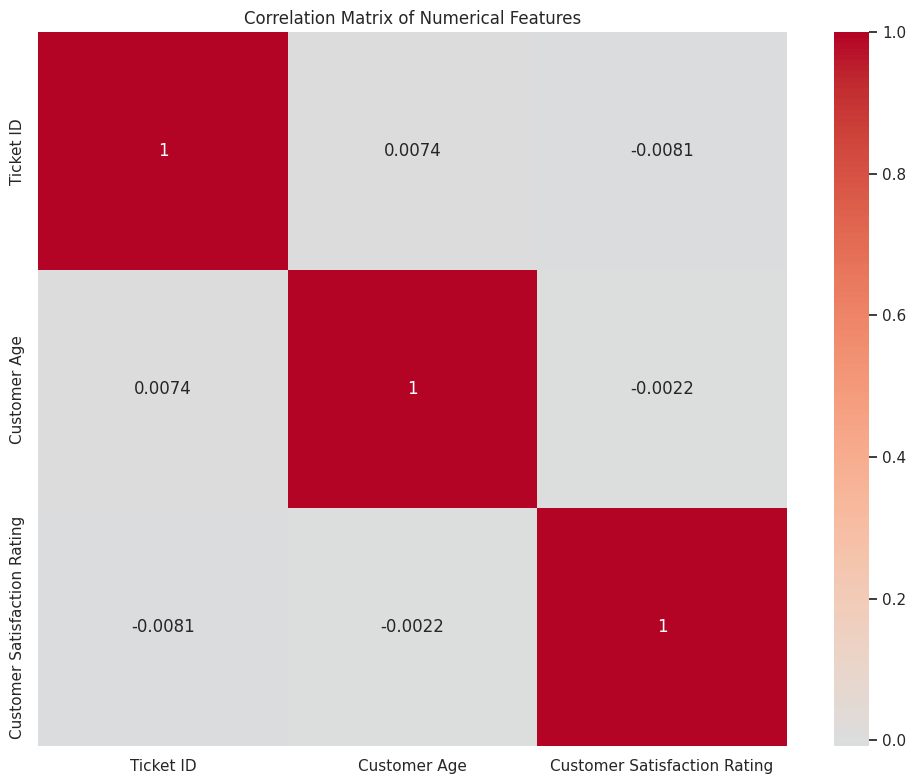

In [ ]:
if 'Customer Satisfaction Rating' in df.columns:
        numerical_cols = df.select_dtypes(include=[np.number]).columns
        if len(numerical_cols) > 1:
            plt.figure(figsize=(10, 8))
            correlation_matrix = df[numerical_cols].corr()
            sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
            plt.title('Correlation Matrix of Numerical Features')
            plt.tight_layout()
            plt.show()

**FEATURE ENGINEERING**

In [ ]:
target_col = 'Customer Satisfaction Rating'
exclude_cols = ['Ticket ID', 'Customer Name', 'Customer Email', target_col]

categorical_cols = [col for col in categorical_cols if col not in exclude_cols]
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: ['Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution']
Numerical columns: ['Customer Age']


In [ ]:
print("Preparing features and target...")

# Drop date and time related columns before encoding and splitting
columns_to_drop = ['Customer Name', 'Customer Email', 'Ticket ID', 'Resolution', 'Date of Purchase', 'First Response Time', 'Time to Resolution']
df_processed = df.drop(columns=columns_to_drop)


# Re-apply encoding to the full df before splitting
label_encoders = {}
for column in df_processed.select_dtypes(include=['object']).columns:
    label_encoders[column] = LabelEncoder()
    df_processed[column] = label_encoders[column].fit_transform(df_processed[column])

# Encode the target variable
label_encoders['Customer Satisfaction Rating'] = LabelEncoder()
df_processed['Customer Satisfaction Rating'] = label_encoders['Customer Satisfaction Rating'].fit_transform(df_processed['Customer Satisfaction Rating'])

X = df_processed.drop('Customer Satisfaction Rating', axis=1)
y = df_processed['Customer Satisfaction Rating']

print(f"Features: {X.shape[1]} columns")
print(f"Target: {len(y)} samples")

Preparing features and target...
Features: 10 columns
Target: 8469 samples


TRAIN MACHINE LEARNING MODELS

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
scaler = StandardScaler()


print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 6775 samples
Testing set: 1694 samples


In [ ]:
def train_satisfaction_models(X, y):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Drop 'Year-Month' column
    X_train = X_train.drop('Year-Month', axis=1)
    X_test = X_test.drop('Year-Month', axis=1)

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train, y_test

In [ ]:
models = {
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
        'SVM': SVC(random_state=42, probability=True)
    }

results = {}

print("Training models...")
# Call the function to get the scaled data
X_train_scaled, X_test_scaled, y_train, y_test = train_satisfaction_models(X,y)

for name, model in models.items():
    print(f"   Training {name}...")



    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
                'model': model,
                'accuracy': accuracy,
                'predictions': y_pred,
                'y_test': y_test
            }
    print(f"{name}: {accuracy:.4f} ({accuracy*100:.2f}%)")

Training models...
   Training Random Forest...
Random Forest: 0.7166 (71.66%)
   Training Logistic Regression...
Logistic Regression: 0.7326 (73.26%)
   Training SVM...
SVM: 0.7220 (72.20%)


In [ ]:
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
print(f"Best model: {best_model_name} with accuracy: {results[best_model_name]['accuracy']:.4f}")

Best model: Logistic Regression with accuracy: 0.7326


In [ ]:
print("Model Performance:")
for name, result in results.items():
    print(f"{name}: Accuracy = {result['accuracy']:.4f}")

best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
print(f"\nBest performing model: {best_model_name} with accuracy {results[best_model_name]['accuracy']:.4f}")

Model Performance:
Random Forest: Accuracy = 0.7166
Logistic Regression: Accuracy = 0.7326
SVM: Accuracy = 0.7220

Best performing model: Logistic Regression with accuracy 0.7326


In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed report
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Random Forest Accuracy: 0.7414 (74.14%)

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       111
           1       0.00      0.00      0.00       110
           2       0.74      1.00      0.85      1256
           3       0.00      0.00      0.00       108
           4       0.00      0.00      0.00       109

    accuracy                           0.74      1694
   macro avg       0.15      0.20      0.17      1694
weighted avg       0.55      0.74      0.63      1694


Confusion Matrix:
 [[   0    0  111    0    0]
 [   0    0  110    0    0]
 [   0    0 1256    0    0]
 [   0    0  108    0    0]
 [   0    0  109    0    0]]


In [ ]:
# Create and fit a new scaler on the training data
scaler_new_data = StandardScaler()
scaler_new_data.fit(X_train.drop('Year-Month', axis=1))

# Example dummy input with 9 values (must match your dataset columns order after dropping 'Year-Month')
new_data = [[32, 1, 450, 15, 5, 4, 5, 3, 2]]

# Convert new_data to a pandas DataFrame with appropriate column names
new_data_df = pd.DataFrame(new_data, columns=X_train.drop('Year-Month', axis=1).columns)

# Scale with the new scaler
new_data_scaled = scaler_new_data.transform(new_data_df)

# Predict
prediction = model.predict(new_data_scaled)
print("Predicted Satisfaction Level:", prediction[0])

Predicted Satisfaction Level: 2


In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42,class_weight="balanced" )

# Assuming X_train_scaled, X_test_scaled, y_train, and y_test are already defined and scaled
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [ ]:
# Model Evaluation
print(f"Accuracy:{accuracy:.4f} ({accuracy*100:.2f}%)")
print("Classification Report:\n", classification_report(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy:0.7326 (73.26%)
Classification Report:
               precision    recall  f1-score   support

           0       0.19      0.21      0.20       115
           1       0.16      0.19      0.17       109
           2       0.92      0.92      0.92      1237
           3       0.19      0.11      0.14       126
           4       0.20      0.22      0.21       107

    accuracy                           0.72      1694
   macro avg       0.33      0.33      0.33      1694
weighted avg       0.72      0.72      0.72      1694

Confusion Matrix:
 [[  24   30   29   16   16]
 [  35   21   17   16   20]
 [  24   28 1143   13   29]
 [  22   28   30   14   32]
 [  19   25   26   13   24]]


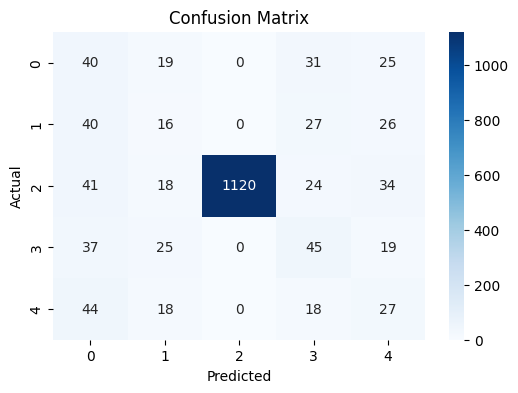

In [ ]:


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.20      0.35      0.25       115
           1       0.17      0.15      0.16       109
           2       1.00      0.91      0.95      1237
           3       0.31      0.36      0.33       126
           4       0.21      0.25      0.23       107

    accuracy                           0.74      1694
   macro avg       0.38      0.40      0.38      1694
weighted avg       0.79      0.74      0.76      1694



In [ ]:
# Identify common issues
common_issues = df['Ticket Subject'].value_counts().head(10)
print("Top 10 Common Issues:")
print(common_issues)

Top 10 Common Issues:
Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64
